In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moabb.paradigms import P300,LeftRightImagery, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = LeftRightImagery(resample=250)
dataset = BNCI2014_004()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[6],
     return_epochs=True
)
"""
session = meta['session'].unique()[3]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
"""

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
720 matching events found
No baseline correction applied


/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr

"\nsession = meta['session'].unique()[3]\nidc = meta['session'] == session\nepochs = epochs[idc]\nlabels = labels[idc]\nmeta = meta[idc]\n"

In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor
from mne.decoding import Scaler

X = epochs.get_data()
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], normalize=True, log=True, n_freqs=4, bin_freq=4)
X = tl.tensor(X)
y = labels
X.shape

(720, 3, 4, 18)

In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning

env: PYTHONWARNINGS=ignore::FutureWarning


In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=4,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    #rank_grid=[1,2,3],
    verbose=True,
    extra_train_info=False,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True, n_splits=10),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/4...

Trying rank (1, 1, 1)	score: 0.9196
Trying rank (2, 2, 2)	score: 0.9167
Trying rank (3, 4, 4)	score: 0.9086
Trying rank (3, 4, 8)	score: 0.9097
Trying rank (3, 4, 16)	score: 0.9043
Trying rank (3, 4, 18)	score: 0.9043

Selected rank (1, 1, 1) with score 0.9196
New ranks: [(1, 1, 1)]


Model selection block 2/4...

Trying rank (1, 1, 1)	score: 0.9122
Trying rank (2, 2, 2)	score: 0.9125
Trying rank (3, 4, 4)	score: 0.9058
Trying rank (3, 4, 8)	score: 0.9081
Trying rank (3, 4, 16)	score: 0.9102
Trying rank (3, 4, 18)	score: 0.9104

Selected rank (2, 2, 2) with score 0.9125
New ranks: [(1, 1, 1), (2, 2, 2)]


Model selection block 3/4...

Trying rank (1, 1, 1)	score: 0.9121
Trying rank (2, 2, 2)	score: 0.9081
Trying rank (3, 4, 4)	score: 0.9112
Trying rank (3, 4, 8)	score: 0.9060
Trying rank (3, 4, 16)	score: 0.9056
Trying rank (3, 4, 18)	score: 0.9072

Selected rank (1, 1, 1) with score 0.9121
New ranks: [(1, 1, 1), (2, 2, 2), (1, 1, 1)]


Model selection blo

GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF(alpha=0.05)),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function NumpyBackend.to_numpy at 0x7f8bf8336020>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (1, 1, 1),
                         'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                         'toeplitz': None, 'tol': 1e-08, 'verbose': False},
            max_blocks=4, n_jobs=1, verbose=True)

In [6]:
bttda.model_select_info_.groupby(['block', 'rank']).val_score.aggregate('mean')

block  rank      
0      (1, 1, 1)     0.919641
       (2, 2, 2)     0.916736
       (3, 4, 4)     0.908587
       (3, 4, 8)     0.909725
       (3, 4, 16)    0.904315
       (3, 4, 18)    0.904315
1      (1, 1, 1)     0.912226
       (2, 2, 2)     0.912494
       (3, 4, 4)     0.905809
       (3, 4, 8)     0.908090
       (3, 4, 16)    0.910183
       (3, 4, 18)    0.910447
2      (1, 1, 1)     0.912116
       (2, 2, 2)     0.908086
       (3, 4, 4)     0.911156
       (3, 4, 8)     0.906022
       (3, 4, 16)    0.905555
       (3, 4, 18)    0.907215
3      (1, 1, 1)     0.899439
       (2, 2, 2)     0.904429
       (3, 4, 4)     0.910464
       (3, 4, 8)     0.904595
       (3, 4, 16)    0.908710
       (3, 4, 18)    0.905448
Name: val_score, dtype: float64

In [7]:
Xt = bttda.transform(X)

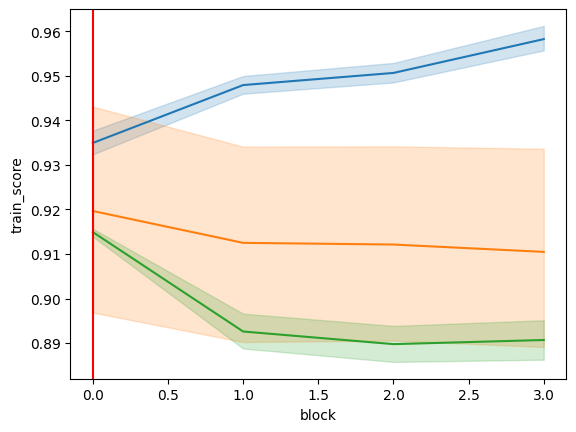

In [8]:
import seaborn as sns 
import matplotlib.pyplot as plt
df_select = bttda.model_select_info_best_
plt.style.use('default')
sns.lineplot(data=df_select, x='block',y='train_score')
sns.lineplot(data=df_select, x='block',y='val_score')
sns.lineplot(data=df_select, x='block',y='test_score')

plt.axvline(bttda.n_blocks_-1, color='red')

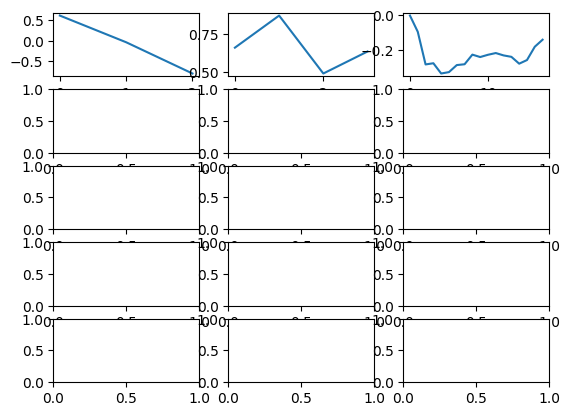

In [9]:
fig, axs = plt.subplots(5,3, sharey=False)
for b,block in enumerate(bttda.blocks_[:5]):
    for k in range(3):
        axs[b,k].plot(tl.to_numpy(block.aps_[k]))

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

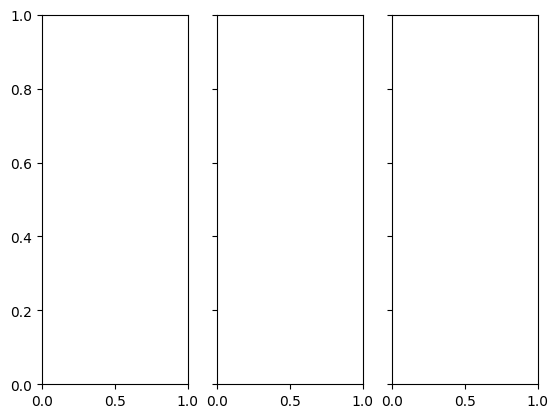

In [10]:
fig, axs = plt.subplots(bttda.n_blocks_,3, sharey=True)
for b,block in enumerate(bttda.blocks_):
    for k in range(3):
        axs[b,k].plot(tl.to_numpy(block.weights_[k]))

block  rank  n_features
0      2     1             0.956944
1      2     1             0.956944
2      2     1             0.956944
3      3     1             0.956944
Name: val_score, dtype: float64

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.lineplot(data=bttda.train_info_, x='block',y='nmse')